In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import ttest_rel
import pandas as pd
from pathlib import Path
import scanpy as sc
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests
from tqdm.notebook import tqdm

In [2]:
adata = sc.read_h5ad('../data/simulation/TM_subset_cnt.h5ad')
celltype_cnts = adata.obs['cell_type'].value_counts()
celltype_cnts = celltype_cnts[celltype_cnts >= 30]

In [3]:
n_bins = 5

In [4]:
files = Path('../data/simulation/causal_simulation').rglob('tc__*.csv')
files = [str(file) for file in files]
ground_truth = {}
for file in tqdm(files, total=len(files)):
    setting = Path(file).parent.name
    runid = Path(file).stem.split('__')[1]
    ground_truth[f'{setting}__run-{runid}'] = pd.read_csv(file, header=None, index_col=None, sep='\t').iloc[0, 0]

  0%|          | 0/17000 [00:00<?, ?it/s]

In [5]:
# load icepop res
res_df = []

for mc_size in [30, 50, 75]:
    base_dir = Path(f"../results/icepop_casual_mc-{mc_size}")
    files = list(base_dir.rglob("celltype__trait*.csv"))
    dfs = []
    for file in tqdm(files, desc=f"mc-{mc_size}", total=len(files)):
        file = Path(file)
        setting = file.parent.name
        runid = file.stem.split("__trait-gwasz__")[1].split(".")[0]
        params = {
            k: float(v)
            for k, v in (p.split("-") for p in setting.split("__"))
        }
        df = pd.read_csv(
            file,
            usecols=["cell_type", "q"],
        )
        df["target"] = ground_truth[f"{setting}__run-{runid}"]
        df["run_idx"] = runid
        df["method"] = f"mc-{mc_size}"
        for k, v in params.items():
            df[k] = v
        dfs.append(df)
    res_df.append(pd.concat(dfs, ignore_index=True))

# final combined result
res_df = pd.concat(res_df, ignore_index=True)
res_df = res_df[res_df['target'] == res_df['cell_type']]
res_df['discovery'] = res_df['q'] <= 0.1

# divide into cell count bins
bins = pd.qcut(celltype_cnts, q=n_bins, labels=[f"bin_{i+1}" for i in range(n_bins)])
res_df['cell_type_cnts'] = list(celltype_cnts.loc[res_df['cell_type']])
res_df['bins'] = list(bins.loc[res_df['cell_type']])

mc-30:   0%|          | 0/17000 [00:00<?, ?it/s]

mc-50:   0%|          | 0/17000 [00:00<?, ?it/s]

mc-75:   0%|          | 0/17000 [00:00<?, ?it/s]

In [6]:
NOISE_SD_FIXED = 1.0
BETA_FIXED = 1.0
FRAC_SIGNAL_FIXED = 0.01
SAMPLE_RATE_FIXED = 1.0

# experiment A: vary signal strength
FRAC_SIGNAL_LIST = [0.001, 0.005, 0.01, 0.05, 0.1]

# experiment B: vary noise_sd
NOISE_SD_LIST = [0.1, 0.5, 1.0, 2.0, 5.0]

# experiment C: vary beta
BETA_LIST = [0.1, 0.5, 1.0, 2.0, 5.0]

# experiment D: vary cell sampling rate
SAMPLE_RATE_LIST = [0.2, 0.4, 0.6, 0.8, 1.0]

# experiment A: vary signal strength

In [7]:
def prepare_plot(res_df, vlabel='sf', bins=None):
    if vlabel == 'sf':
        a_df = res_df[
            (res_df['sf'].isin(FRAC_SIGNAL_LIST)) &
            (res_df['ns'] == NOISE_SD_FIXED) &
            (res_df['b'] == BETA_FIXED) &
            (res_df['sr'] == SAMPLE_RATE_FIXED)
        ]
    elif vlabel == 'ns':
        a_df = res_df[
            (res_df['sf'] == FRAC_SIGNAL_FIXED) &
            (res_df['ns'].isin(NOISE_SD_LIST)) &
            (res_df['b'] == BETA_FIXED) &
            (res_df['sr'] == SAMPLE_RATE_FIXED)
        ]
    elif vlabel == 'b':
        a_df = res_df[
            (res_df['sf'] == FRAC_SIGNAL_FIXED) &
            (res_df['ns'] == NOISE_SD_FIXED) &
            (res_df['b'].isin(BETA_LIST)) &
            (res_df['sr'] == SAMPLE_RATE_FIXED)
        ]
    elif vlabel == 'sr':
        a_df = res_df[
            (res_df['sf'] == FRAC_SIGNAL_FIXED) &
            (res_df['ns'] == NOISE_SD_FIXED) &
            (res_df['b'] == BETA_FIXED) &
            (res_df['sr'].isin(SAMPLE_RATE_LIST))
        ]
    if bins:
        a_df = a_df[a_df['bins'] == bins]
    df = (
        a_df
        .groupby([vlabel, "seed", "method"])["discovery"]
        .mean()
        .rename("power")
        .reset_index()
    )

    return df

def overall_perf(
    res_df, vlabel, outfile,
    xlabel="Signal fraction",
    ylabel="Power", show_legend=False
):

    df = prepare_plot(res_df, vlabel=vlabel)
    stats_results = compute_pairwise_tests(df, x_col=vlabel)

    methods = df["method"].unique()

    plt.figure(figsize=(5, 3.5))

    sns.barplot(
        data=df,
        x=vlabel,
        y="power",
        hue="method",
        errorbar=None,
    )

    sns.stripplot(
        data=df,
        x=vlabel,
        y="power",
        hue="method",
        dodge=True,
        jitter=0.15,
        palette=["black"] * len(methods),
        size=4,
        alpha=0.8,
        legend=False,
    )

    ax = plt.gca()
    if not show_legend:
        ax.legend().remove()
    else:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles[:len(methods)],
            labels[:len(methods)],
            title="Metacell size",
            fontsize=9.5,
            title_fontsize=9.5,
            frameon=False,
            loc="best"
        )

    # Keep y-axis tight
    ax.set_ylim(-0.05, 1.05)
    ax.set_yticks(np.linspace(0, 1, 6))

    def stars(p):
        if p < 0.001: return "***"
        elif p < 0.01: return "**"
        elif p < 0.05: return "*"
        else: return "ns"

    x_levels = df[vlabel].unique()

    # bracket vertical placement (axes coordinates)
    y1 = 1.02
    y2 = 1.15
    h = 0.03
    trans = ax.get_xaxis_transform()

    for i, xval in enumerate(x_levels):

        p13 = stats_results[xval]["p13"]   # 1 vs 3
        p12 = stats_results[xval]["p12"]   # 1 vs 2

        # ----- 1 vs 3 -----
        ax.plot([i-0.25, i-0.25, i+0.25, i+0.25],
                [y1, y1+h, y1+h, y1],
                transform=trans,
                lw=1.5, c="black",
                clip_on=False)

        ax.text(i,
                y1+h,
                stars(p13),
                ha="center", va="bottom",
                fontsize=12,
                transform=trans,
                clip_on=False)

        # ----- 2 vs 3 -----
        ax.plot([i, i, i+0.25, i+0.25],
                [y2, y2+h, y2+h, y2],
                transform=trans,
                lw=1.5, c="black",
                clip_on=False)

        ax.text(i+0.125,
                y2+h,
                stars(p12),   # careful: this is p12 = 1 vs 2
                ha="center", va="bottom",
                fontsize=12,
                transform=trans,
                clip_on=False)

    # Styling
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    ax.set_yticklabels([f"{x:.1f}" for x in np.linspace(0, 1, 6)])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(outfile)


def split_by_ct_perf(
    res_df, vlabel, outfile,
    xlabel="Signal fraction",
    ylabel="Power", xticks_order=None
):

    fig, axs = plt.subplots(
        ncols=5, nrows=1,
        sharey=True,
        sharex=True,
        figsize=(15, 3.5),
    )

    for i in range(5):
        idx = i + 1
        cur_bin = f"bin_{idx}"

        df = prepare_plot(res_df, vlabel=vlabel, bins=cur_bin)
        stats_results = compute_pairwise_tests(df, x_col=vlabel)

        ax = axs[i]

        # ---- enforce categorical x ----
        if xticks_order is None:
            x_order = list(pd.unique(df[vlabel]))
        else:
            x_order = list(xticks_order)

        df = df.copy()
        df["_xcat"] = pd.Categorical(df[vlabel], categories=x_order, ordered=True)

        sns.barplot(
            data=df,
            x="_xcat",
            y="power",
            hue="method",
            errorbar=None,
            ax=ax,
            order=x_order
        )

        sns.stripplot(
            data=df,
            x="_xcat",
            y="power",
            hue="method",
            dodge=True,
            jitter=0.15,
            palette=["black"] * df["method"].nunique(),
            size=3.5,
            clip_on=False,
            ax=ax,
            alpha=0.8,
        )

        ax.legend().remove()

        ax.set_ylim(-0.03, 1.03)
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])

        # ---- compute dodge offsets ----
        methods = list(pd.unique(df["method"]))
        n_hue = len(methods)

        total_width = 0.8
        bar_width = total_width / n_hue
        offsets = np.linspace(
            -total_width/2 + bar_width/2,
            total_width/2 - bar_width/2,
            n_hue
        )

        def stars(p):
            if p < 0.001: return "***"
            elif p < 0.01: return "**"
            elif p < 0.05: return "*"
            else: return "ns"

        y1, y2, h = 1.01, 1.07, 0.02
        trans = ax.get_xaxis_transform()

        for j, xval in enumerate(x_order):
            if xval not in stats_results:
                continue

            p13 = stats_results[xval]["p13"]  # 1 vs 3
            p23 = stats_results[xval]["p23"]  # 2 vs 3  (must exist!)

            x_m1 = j + offsets[0]
            x_m2 = j + offsets[1]
            x_m3 = j + offsets[2]

            # ----- 1 vs 3 -----
            ax.plot([x_m1, x_m1, x_m3, x_m3],
                    [y1, y1+h, y1+h, y1],
                    lw=1.2, c="black",
                    transform=trans,
                    clip_on=False)

            ax.text((x_m1 + x_m3)/2, y1+h,
                    stars(p13),
                    ha="center", va="bottom",
                    fontsize=9,
                    transform=trans,
                    clip_on=False)

            # ----- 2 vs 3 -----
            ax.plot([x_m2, x_m2, x_m3, x_m3],
                    [y2, y2+h, y2+h, y2],
                    lw=1.2, c="black",
                    transform=trans,
                    clip_on=False)

            ax.text((x_m2 + x_m3)/2, y2+h,
                    stars(p23),
                    ha="center", va="bottom",
                    fontsize=9,
                    transform=trans,
                    clip_on=False)

        # Titles
        min_cnt = celltype_cnts[bins[bins == cur_bin].index].min()
        max_cnt = celltype_cnts[bins[bins == cur_bin].index].max()
        title_bin = cur_bin.replace("_", " ")
        ax.set_title(
            f"Cell type {title_bin}: {min_cnt:,}-{max_cnt:,}",
            pad=29
        )

        ax.set_xlabel("")
        if i == 0:
            ax.set_ylabel(ylabel, fontsize=14)
        else:
            ax.set_ylabel("")

        ax.tick_params(axis="x", labelsize=12)
        ax.tick_params(axis="y", labelsize=12)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.subplots_adjust(
        left=0.04,
        right=0.995,
        bottom=0.18,
        top=0.88,
        wspace=0.15
    )

    fig.supxlabel(xlabel, fontsize=14)
    plt.savefig(outfile, bbox_inches="tight")


def compute_pairwise_tests(df, x_col, method_col="method", y_col="power"):
    """
    Compute paired t-tests:
    - first method vs second
    - first method vs third
    
    Returns dictionary:
        {x_level: {"p12": val, "p13": val}}
    """

    results = {}
    methods = df[method_col].unique()

    if len(methods) < 3:
        raise ValueError("Need at least 3 methods for pairwise comparison.")

    for xval in df[x_col].unique():
        sub = df[df[x_col] == xval]

        m1 = sub[sub[method_col] == methods[0]][y_col].values
        m2 = sub[sub[method_col] == methods[1]][y_col].values
        m3 = sub[sub[method_col] == methods[2]][y_col].values

        p12 = ttest_rel(m1, m2).pvalue
        p13 = ttest_rel(m1, m3).pvalue
        p23 = ttest_rel(m2, m3).pvalue

        results[xval] = {"p12": p12, "p13": p13, "p23": p13}

    return results

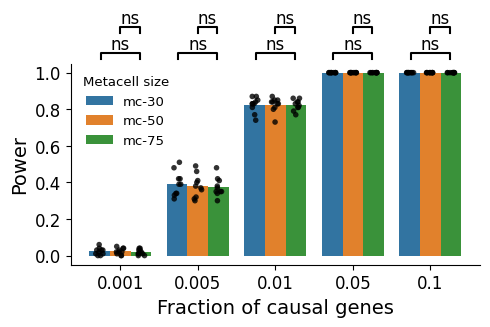

In [8]:
vlabel = 'sf'
overall_perf(
    res_df, vlabel,
    "../paper/schematics/mc_legend.pdf",
    xlabel="Fraction of causal genes",
    ylabel='Power', show_legend=True
)

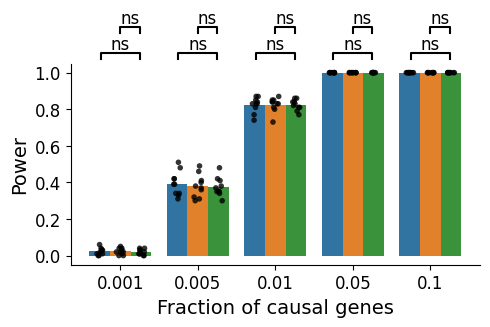

In [9]:
vlabel = 'sf'
overall_perf(
    res_df, vlabel,
    "../paper/supp/causal_sf_mc.pdf",
    xlabel="Fraction of causal genes",
    ylabel='Power'
)

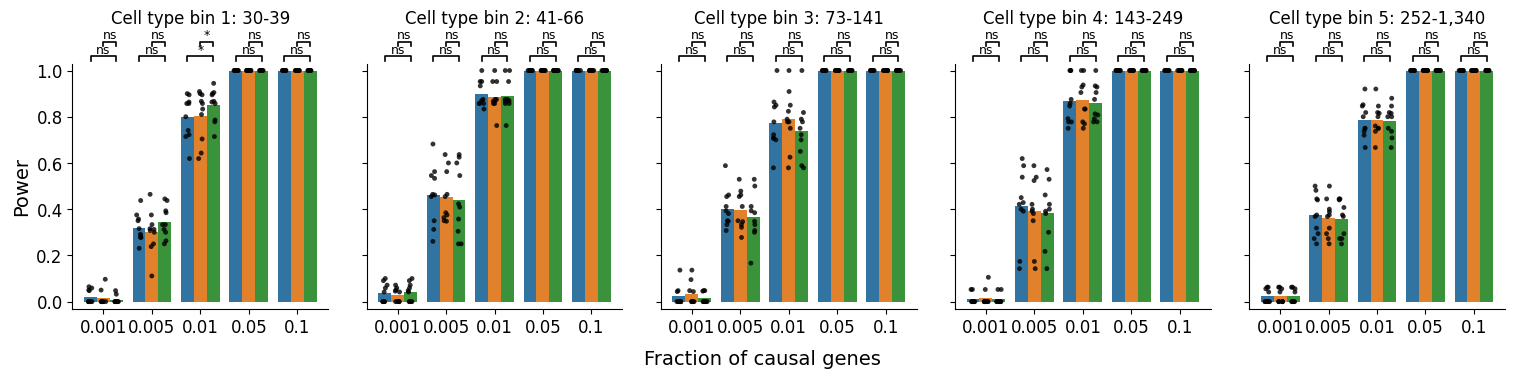

In [10]:
split_by_ct_perf(
    res_df, vlabel,
    "../paper/supp/causal_sf_ctsize_mc.pdf",
    xlabel="Fraction of causal genes",
    ylabel='Power'
)

# experiment B: vary noise_sd

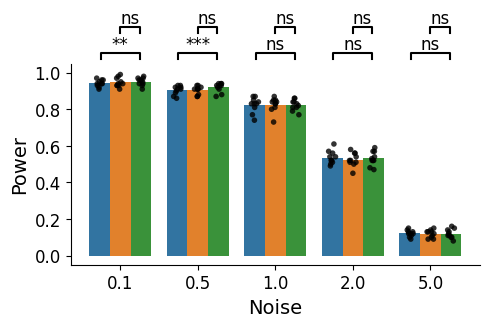

In [11]:
vlabel = 'ns'
overall_perf(
    res_df, vlabel, "../paper/supp/causal_ns_mc.pdf",
    xlabel="Noise",
    ylabel='Power',
)

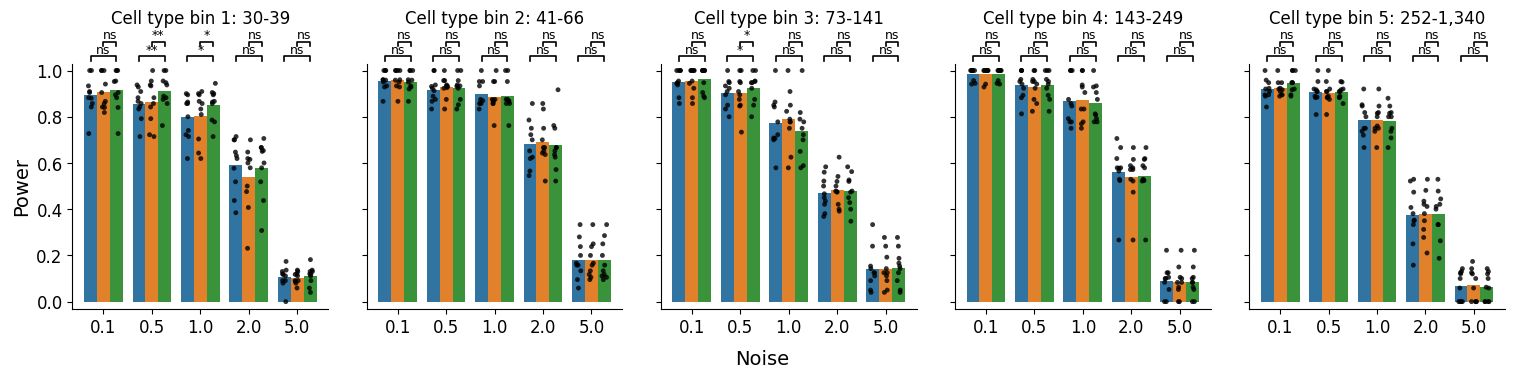

In [12]:
split_by_ct_perf(
    res_df, vlabel,
    "../paper/supp/causal_ns_ctsize_mc.pdf",
    xlabel="Noise",
    ylabel='Power'
)

# experiment C: vary beta

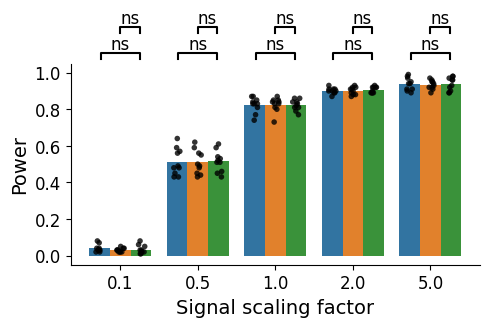

In [13]:
vlabel = 'b'
overall_perf(
    res_df, vlabel, "../paper/supp/causal_factor_mc.pdf",
    xlabel="Signal scaling factor",
    ylabel='Power',
)

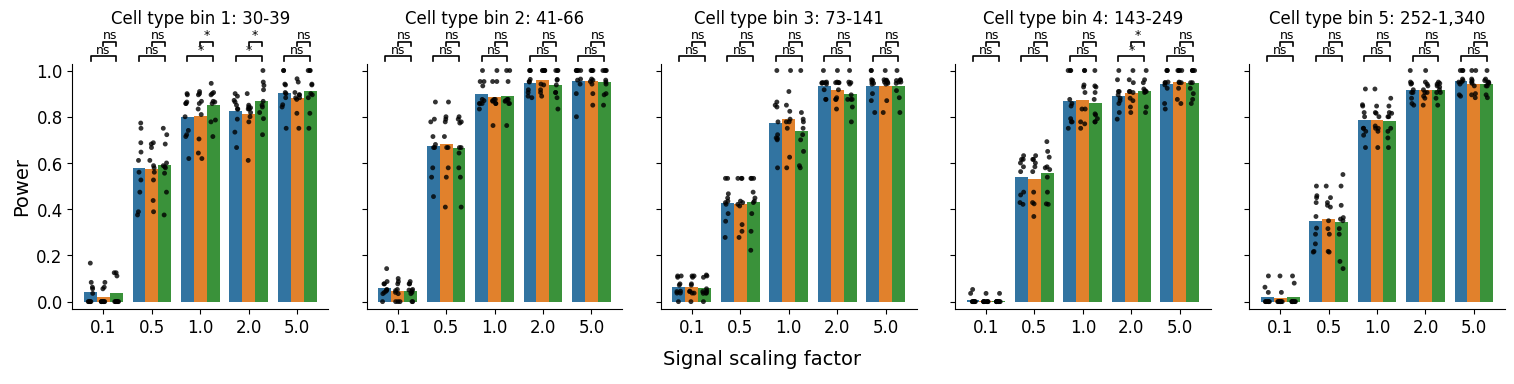

In [14]:
split_by_ct_perf(
    res_df, vlabel,
    "../paper/supp/causal_factor_ctsize_mc.pdf",
    xlabel="Signal scaling factor",
    ylabel='Power'
)

# experiment D: vary sample rate

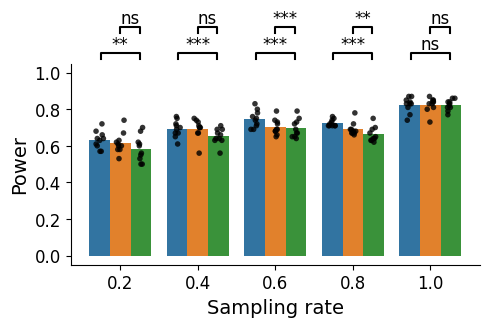

In [15]:
vlabel = 'sr'
overall_perf(
    res_df, vlabel, "../paper/supp/causal_sr_mc.pdf",
    xlabel="Sampling rate",
    ylabel='Power',
)

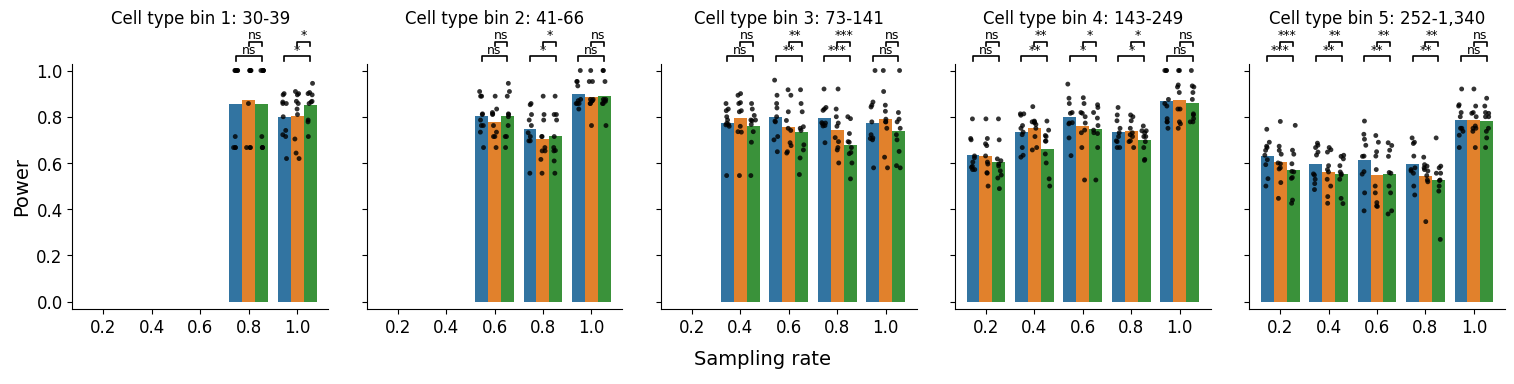

In [16]:
split_by_ct_perf(
    res_df, vlabel,
    "../paper/supp/causal_sr_ctsize_mc.pdf",
    xlabel="Sampling rate",
    ylabel='Power',
    xticks_order=[0.2, 0.4, 0.6, 0.8, 1.0]
)